In [11]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import (
    kl_gamma,
    kl_gaussian_gamma_covariance_param,
    get_optimal_gaussian_gamma,
)


class TPR(nn.Module):
    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=-4.0, scale=1.0)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # Register non-trainable buffers for the Normal-Gamma distribution q(f,r)
        self.register_buffer('m_f', torch.zeros(self.N, 1, dtype=dtype))
        self.register_buffer('S_f', torch.eye(self.N, dtype=dtype))
        self.register_buffer('alpha_r', dof_func / 2.0)
        self.register_buffer('beta_r', dof_func / 2.0)

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, K_XX, local_params):
        alpha_lambda, beta_lambda = local_params
        params = self._get_hyperparams()
        
        # 1. Expected Log-Likelihood
        E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
        E_log_lambda = torch.digamma(alpha_lambda) - torch.log(beta_lambda.clamp(min=EPSILON))
        
        E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
        var_f = E_r_inv * torch.diag(self.S_f)
        E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
        
        noise_var = params["noisescale"]
        exp_log_lik = torch.sum(
            -0.5 * torch.log(2 * torch.pi * noise_var) + 0.5 * E_log_lambda - 0.5 * E_lambda * E_sq_err / noise_var
        )
        
        # 2. KL Divergence (Gamma)
        p_alpha_lambda, p_beta_lambda = params['dof_lik'] / 2.0, params['dof_lik'] / 2.0
        kl_lambda = kl_gamma(alpha_lambda, beta_lambda, p_alpha_lambda, p_beta_lambda).sum()

        # 2. KL Divergence (Gaussian-Gamma)
        p_alpha_r, p_beta_r = params['dof_func'] / 2.0, params['dof_func'] / 2.0
        prior_mean_f = torch.zeros_like(self.m_f.squeeze())
        kl_f_r = kl_gaussian_gamma_covariance_param(
            mu_q=self.m_f.squeeze(), S_q=self.S_f, alpha_q=self.alpha_r, beta_q=self.beta_r,
            mu_p=prior_mean_f, K_p=K_XX.to_dense(), alpha_p=p_alpha_r, beta_p=p_beta_r
        )
        
        return exp_log_lik - kl_lambda - kl_f_r


    def _e_step(self, K_XX_op, params):
        with torch.no_grad():
            identity = torch.eye(self.N, device=self.device, dtype=self.X_full.dtype)
            sigma2 = params['noisescale']

            # Update q(λ) parameters
            E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
            var_f = E_r_inv * torch.diag(self.S_f)
            E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
            alpha_lambda = (params['dof_lik'] / 2.0 + 0.5).expand(self.N)
            beta_lambda = params['dof_lik'] / 2.0 + 0.5 * E_sq_err / sigma2
            
            # Update q(f), q(r) parameters independently
            E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
            E_r = self.alpha_r / self.beta_r.clamp(min=EPSILON)
            K_XX_inv = K_XX_op.solve(identity)
            scaled_K_XX_inv = K_XX_inv * E_r

            target_S_f_inv = scaled_K_XX_inv + torch.diag(E_lambda / sigma2)
            target_S_f_inv_op = to_linear_operator(target_S_f_inv)
            target_S_f = target_S_f_inv_op.solve(identity)
            target_m_f_term = (E_lambda * self.y_full.squeeze()) / sigma2
            target_m_f = target_S_f @ target_m_f_term.unsqueeze(1)
            
            target_alpha_r = params['dof_func'] / 2.0 + self.N / 2.0
            trace_term = torch.trace(K_XX_inv @ target_S_f)
            K_inv_m = K_XX_inv @ target_m_f
            quad_term = (target_m_f.T @ K_inv_m).squeeze()
            target_beta_r = params['dof_func'] / 2.0 + (trace_term + quad_term) / 2.0

            # Update q(f, r) via projection
            _, S_f_proj, _, _ = get_optimal_gaussian_gamma(
                target_m_f, target_S_f, target_alpha_r, target_beta_r
            )

            self.m_f.data      = target_m_f
            self.S_f.data      = S_f_proj
            self.alpha_r.data  = target_alpha_r
            self.beta_r.data   = target_beta_r

            return alpha_lambda, beta_lambda

    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    def fit(
        self, 
        epochs=100,
        hyper_lr=0.01,
        X_test=None, y_test=None, eval_interval=10
    ):
        parameters_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_",""), "MLE") != 'FIX']
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None

        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'lengthscale': [], 'outputscale': [],
            'dof_func': [], 'dof_lik': [], 'noisescale': [], 'eval_epochs': [],
            'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):
            self.train()
            fit_start_time = time.time()

            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            local_params = self._e_step(K_XX_op, params)
            elbo = self._calculate_elbo(K_XX_op, local_params)
            log_prior = self._calculate_log_prior(params)
            loss = - (elbo + log_prior)
            
            self._m_step(optimizer, loss)
            fit_end_time = time.time()

            with torch.no_grad():
                params_final = self._get_hyperparams()
                history['elbo'].append(elbo.item())
                history['log_prior'].append(log_prior.item())
                history['loss'].append(loss.item())
                history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
                history['outputscale'].append(params_final['outputscale'].item())
                history['noisescale'].append(params_final['noisescale'].item())
                history['dof_func'].append(params_final['dof_func'].item())
                history['dof_lik'].append(params_final['dof_lik'].item())
                history['fit_times'].append(fit_end_time - fit_start_time)
                
            if (epoch + 1) % eval_interval == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in params_final['lengthscale']])
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {params_final['outputscale']:.3f} | noise_var: {params_final['noisescale']:.3f} | dof_f: {params_final['dof_func']:.2f} | dof_l: {params_final['dof_lik']:.2f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Optimization finished.")
        return history

    def predict(self, X_test):
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
            
        self.eval()
        with torch.no_grad():
            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_full, params['lengthscale'], params['outputscale'])
            k_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            # Predictive Location (mean): mu_star = K_*X @ K_XX^-1 @ m_f
            K_XX_inv_mf = K_XX_op.solve(self.m_f)
            mu_star = K_star_X @ K_XX_inv_mf
            
            # Predictive Degrees of Freedom
            dof_star = 2 * self.alpha_r
            
            # Predictive Scale
            A = K_XX_op.solve(K_star_X.T).T
            
            term1 = k_star_star - torch.sum(A * K_star_X, dim=1)
            term2 = torch.sum((A @ self.S_f) * A, dim=1)
            scale_sq_star_f = (self.beta_r / self.alpha_r.clamp(min=EPSILON)) * (term1 + term2)
            
            dof_lik = params['dof_lik']
            noise_var = params['noisescale']
            expected_noise_var = noise_var * dof_lik / (dof_lik - 2).clamp(min=EPSILON)
            
            return {
                'loc': mu_star.squeeze(), 
                'scale_sq': (scale_sq_star_f + expected_noise_var).clamp(min=EPSILON), 
                'dof': dof_star.clamp(min=EPSILON)
            }

    def _evaluate(self, X_test, y_test):
        f_pred_tensor = self.predict(X_test)
        f_pred_numpy = f_pred_tensor['loc'].cpu().numpy()
        y_true_numpy = y_test.cpu().numpy().squeeze()
        metrics = {'rmse': np.sqrt(mean_squared_error(y_true_numpy, f_pred_numpy))}
        return metrics


In [ ]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import (
    kl_gamma,
    kl_gaussian_gamma_covariance_param,
    get_optimal_gaussian_gamma,
)


class TPR(nn.Module):
    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=-4.0, scale=1.0)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # Define trainable variational parameters for the Normal-Gamma distribution q(f,r)
        self.m_f = nn.Parameter(torch.zeros(self.N, 1, dtype=dtype))

        # For S_f, we parameterize its Cholesky factor L_f to ensure S_f is positive semi-definite.
        # S_f = L_f @ L_f.T. L_f is a lower triangular matrix with a positive diagonal.
        # We store the log of the diagonal elements and the lower off-diagonal elements.
        # Initializing S_f to the identity matrix means L_f is also the identity matrix.
        # Thus, the initial log of the diagonal is zeros, and the off-diagonal is zeros.
        self.chol_S_f_log_diag = nn.Parameter(torch.zeros(self.N, dtype=dtype))
        self.chol_S_f_off_diag = nn.Parameter(torch.zeros(self.N, self.N, dtype=dtype))

        # For alpha_r and beta_r, we store their logs to ensure they remain positive.
        initial_alpha_r = dof_func / 2.0
        initial_beta_r = dof_func / 2.0
        self.log_alpha_r = nn.Parameter(torch.log(initial_alpha_r))
        self.log_beta_r = nn.Parameter(torch.log(initial_beta_r))

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    @property
    def S_f(self):
        """
        Constructs the covariance matrix S_f from its Cholesky factor parameterization.
        S_f is guaranteed to be positive semi-definite.
        """
        L_diag = torch.diag_embed(torch.exp(self.chol_S_f_log_diag))
        L_off_diag = torch.tril(self.chol_S_f_off_diag, diagonal=-1)
        L_f = L_diag + L_off_diag
        return L_f @ L_f.transpose(-1, -2)

    @property
    def alpha_r(self):
        """Returns the positive shape parameter of the Gamma distribution."""
        return torch.exp(self.log_alpha_r)

    @property
    def beta_r(self):
        """Returns the positive rate parameter of the Gamma distribution."""
        return torch.exp(self.log_beta_r)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

In [1]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import (
    kl_gamma,
    kl_gaussian_gamma_covariance_param,
)


class TPR(nn.Module):
    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=-4.0, scale=1.0)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # Define trainable variational parameters for q(f,r)
        self.m_f = nn.Parameter(torch.zeros(self.N, 1, dtype=dtype))
        self.chol_S_f_log_diag = nn.Parameter(torch.zeros(self.N, dtype=dtype))
        self.chol_S_f_off_diag = nn.Parameter(torch.zeros(self.N, self.N, dtype=dtype))
        initial_alpha_r = dof_func / 2.0
        initial_beta_r = dof_func / 2.0
        self.log_alpha_r = nn.Parameter(torch.log(initial_alpha_r))
        self.log_beta_r = nn.Parameter(torch.log(initial_beta_r))

        # Define trainable variational parameters for q(lambda)
        initial_alpha_lambda = (dof_lik / 2.0).repeat(self.N)
        initial_beta_lambda = (dof_lik / 2.0).repeat(self.N)
        self.log_alpha_lambda = nn.Parameter(torch.log(initial_alpha_lambda))
        self.log_beta_lambda = nn.Parameter(torch.log(initial_beta_lambda))

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    @property
    def S_f(self):
        """Constructs the covariance matrix S_f from its Cholesky factor."""
        L_diag = torch.diag_embed(torch.exp(self.chol_S_f_log_diag))
        L_off_diag = torch.tril(self.chol_S_f_off_diag, diagonal=-1)
        L_f = L_diag + L_off_diag
        return L_f @ L_f.transpose(-1, -2)

    @property
    def alpha_r(self):
        """Returns the positive shape parameter of the Gamma distribution for r."""
        return torch.exp(self.log_alpha_r)

    @property
    def beta_r(self):
        """Returns the positive rate parameter of the Gamma distribution for r."""
        return torch.exp(self.log_beta_r)

    @property
    def alpha_lambda(self):
        """Returns the positive shape parameter of the Gamma distribution for lambda."""
        return torch.exp(self.log_alpha_lambda)

    @property
    def beta_lambda(self):
        """Returns the positive rate parameter of the Gamma distribution for lambda."""
        return torch.exp(self.log_beta_lambda)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, K_XX):
        params = self._get_hyperparams()
        
        # 1. Expected Log-Likelihood
        E_lambda = self.alpha_lambda / self.beta_lambda.clamp(min=EPSILON)
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda.clamp(min=EPSILON))
        
        E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)
        var_f = E_r_inv.squeeze() * torch.diag(self.S_f)
        E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f
        
        noise_var = params["noisescale"]
        exp_log_lik = torch.sum(
            -0.5 * torch.log(2 * torch.pi * noise_var) + 0.5 * E_log_lambda - 0.5 * E_lambda * E_sq_err / noise_var
        )
        
        # 2. KL Divergence q(lambda) || p(lambda)
        p_alpha_lambda, p_beta_lambda = params['dof_lik'] / 2.0, params['dof_lik'] / 2.0
        kl_lambda = kl_gamma(self.alpha_lambda, self.beta_lambda, p_alpha_lambda, p_beta_lambda).sum()

        # 3. KL Divergence q(f,r) || p(f,r)
        p_alpha_r, p_beta_r = params['dof_func'] / 2.0, params['dof_func'] / 2.0
        prior_mean_f = torch.zeros_like(self.m_f.squeeze())
        kl_f_r = kl_gaussian_gamma_covariance_param(
            mu_q=self.m_f.squeeze(), S_q=self.S_f, alpha_q=self.alpha_r, beta_q=self.beta_r,
            mu_p=prior_mean_f, K_p=K_XX.to_dense(), alpha_p=p_alpha_r, beta_p=p_beta_r
        )
        
        return exp_log_lik - kl_lambda - kl_f_r
    
    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    def fit(
        self, 
        epochs=100,
        hyper_lr=0.01,
        X_test=None, y_test=None, eval_interval=10
    ):
        # All nn.Parameters are optimized jointly
        parameters_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_",""), "MLE") != 'FIX']
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None

        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'lengthscale': [], 'outputscale': [],
            'dof_func': [], 'dof_lik': [], 'noisescale': [], 'eval_epochs': [],
            'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):
            self.train()
            fit_start_time = time.time()

            params = self._get_hyperparams()
            K_XX_base = self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale'])
            K_XX_op = to_linear_operator(K_XX_base).add_jitter(JITTER)

            elbo = self._calculate_elbo(K_XX_op)
            log_prior = self._calculate_log_prior(params)
            loss = - (elbo + log_prior)
            
            self._m_step(optimizer, loss)
            fit_end_time = time.time()

            with torch.no_grad():
                params_final = self._get_hyperparams()
                history['elbo'].append(elbo.item())
                history['log_prior'].append(log_prior.item())
                history['loss'].append(loss.item())
                history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
                history['outputscale'].append(params_final['outputscale'].item())
                history['noisescale'].append(params_final['noisescale'].item())
                history['dof_func'].append(params_final['dof_func'].item())
                history['dof_lik'].append(params_final['dof_lik'].item())
                history['fit_times'].append(fit_end_time - fit_start_time)
                
            if (epoch + 1) % eval_interval == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in params_final['lengthscale']])
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {params_final['outputscale']:.3f} | noise_var: {params_final['noisescale']:.3f} | dof_f: {params_final['dof_func']:.2f} | dof_l: {params_final['dof_lik']:.2f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Optimization finished.")
        return history


    def predict(self, X_test):
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
            
        self.eval()
        with torch.no_grad():
            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_full, params['lengthscale'], params['outputscale'])
            k_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            # Predictive Location (mean): mu_star = K_*X @ K_XX^-1 @ m_f
            K_XX_inv_mf = K_XX_op.solve(self.m_f)
            mu_star = K_star_X @ K_XX_inv_mf
            
            # Predictive Degrees of Freedom
            dof_star = 2 * self.alpha_r
            
            # Predictive Scale
            A = K_XX_op.solve(K_star_X.T).T
            
            term1 = k_star_star - torch.sum(A * K_star_X, dim=1)
            term2 = torch.sum((A @ self.S_f) * A, dim=1)
            scale_sq_star_f = (self.beta_r / self.alpha_r.clamp(min=EPSILON)) * (term1 + term2)
            
            dof_lik = params['dof_lik']
            noise_var = params['noisescale']
            expected_noise_var = noise_var * dof_lik / (dof_lik - 2).clamp(min=EPSILON)
            
            return {
                'loc': mu_star.squeeze(), 
                'scale_sq': (scale_sq_star_f + expected_noise_var).clamp(min=EPSILON), 
                'dof': dof_star.clamp(min=EPSILON)
            }

    def _evaluate(self, X_test, y_test):
        f_pred_tensor = self.predict(X_test)
        f_pred_numpy = f_pred_tensor['loc'].cpu().numpy()
        y_true_numpy = y_test.cpu().numpy().squeeze()
        metrics = {'rmse': np.sqrt(mean_squared_error(y_true_numpy, f_pred_numpy))}
        return metrics

In [3]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import (
    kl_gamma,
    kl_gaussian_gamma_covariance_param,
)


class TPR(nn.Module):
    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=-4.0, scale=1.0)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # ---- ここから変分パラメータを勾配最適化するために Parameter に変更 ----
        # m_f: mean of q(f) (N x 1)
        self.m_f = nn.Parameter(torch.zeros(self.N, 1, dtype=dtype, device=self.device))

        # S_f: 保持は下三角パラメータ L で行い S = L @ L.T を常に PSD にする
        L_init = torch.eye(self.N, dtype=dtype, device=self.device)
        self.L_f_raw = nn.Parameter(L_init)  # we will take lower-tri and form S = L @ L.T

        # q(r) のパラメータ (正値にするため log 空間で保持)
        init_alpha_r = (dof_func / 2.0).to(self.device, dtype=dtype)
        init_beta_r = (dof_func / 2.0).to(self.device, dtype=dtype)
        self.log_alpha_r = nn.Parameter(torch.log(init_alpha_r))
        self.log_beta_r = nn.Parameter(torch.log(init_beta_r))

        # q(lambda) の変分パラメータ（各データ点）も勾配最適化する
        # 初期化は dof_lik/2 + 0.5 と dof_lik/2（ある程度妥当な初期値）
        init_alpha_lambda = (dof_lik / 2.0 + 0.5).expand(self.N).to(self.device, dtype=dtype)
        init_beta_lambda = (dof_lik / 2.0).expand(self.N).to(self.device, dtype=dtype)
        self.log_alpha_lambda = nn.Parameter(torch.log(init_alpha_lambda))
        self.log_beta_lambda = nn.Parameter(torch.log(init_beta_lambda))
        # ---- ここまで ----

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    # 便利プロパティ：勾配で更新するパラメータから実際の正値量を計算
    @property
    def S_f(self):
        # 下三角を取り、S = L @ L.T として PSD を保証。対角に小さい jitter を足す。
        L = torch.tril(self.L_f_raw)
        S = L @ L.T
        # ensure numerical stability
        S = S + EPSILON * torch.eye(self.N, device=self.device, dtype=self.X_full.dtype)
        return S

    @property
    def alpha_r(self):
        return torch.exp(self.log_alpha_r).clamp(min=EPSILON)

    @property
    def beta_r(self):
        return torch.exp(self.log_beta_r).clamp(min=EPSILON)

    @property
    def alpha_lambda(self):
        return torch.exp(self.log_alpha_lambda).clamp(min=EPSILON)

    @property
    def beta_lambda(self):
        return torch.exp(self.log_beta_lambda).clamp(min=EPSILON)

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, K_XX,):
        """
        変分パラメータ（m_f, S_f, alpha_r/beta_r, alpha_lambda/beta_lambda）は
        全て nn.Parameter に置き換えてあるため、ここではそれらを用いて
        ELBO を評価（勾配は backward() により流れる）。
        """
        params = self._get_hyperparams()

        # --- q(lambda) の期待値・期待対数 ---
        alpha_lambda = self.alpha_lambda
        beta_lambda = self.beta_lambda
        E_lambda = alpha_lambda / beta_lambda.clamp(min=EPSILON)
        E_log_lambda = torch.digamma(alpha_lambda) - torch.log(beta_lambda.clamp(min=EPSILON))

        # --- q(r) に関する期待逆分散 ---
        E_r_inv = self.beta_r / (self.alpha_r - 1.0).clamp(min=EPSILON)

        # var_f: 各データ点での分散は E_r_inv * diag(S_f)
        var_f = E_r_inv * torch.diag(self.S_f)
        E_sq_err = (self.y_full.squeeze() - self.m_f.squeeze())**2 + var_f

        noise_var = params["noisescale"]
        exp_log_lik = torch.sum(
            -0.5 * torch.log(2 * torch.pi * noise_var) + 0.5 * E_log_lambda - 0.5 * E_lambda * E_sq_err / noise_var
        )

        # KL(q(lambda) || p(lambda)) : p is Gamma(dof_lik/2, dof_lik/2)
        p_alpha_lambda, p_beta_lambda = params['dof_lik'] / 2.0, params['dof_lik'] / 2.0
        kl_lambda = kl_gamma(alpha_lambda, beta_lambda, p_alpha_lambda, p_beta_lambda).sum()

        # KL(q(f,r) || p(f,r))
        p_alpha_r, p_beta_r = params['dof_func'] / 2.0, params['dof_func'] / 2.0
        prior_mean_f = torch.zeros_like(self.m_f.squeeze())
        kl_f_r = kl_gaussian_gamma_covariance_param(
            mu_q=self.m_f.squeeze(), S_q=self.S_f, alpha_q=self.alpha_r, beta_q=self.beta_r,
            mu_p=prior_mean_f, K_p=K_XX.to_dense(), alpha_p=p_alpha_r, beta_p=p_beta_r
        )

        return exp_log_lik - kl_lambda - kl_f_r

    # _e_step は残すが、fit() では使わない（勾配で最適化するため）
    def _e_step(self, K_XX_op, params):
        raise NotImplementedError("E-step is not used: variational parameters are optimized with gradients.")

    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    def fit(
        self, 
        epochs=100,
        hyper_lr=0.01,
        X_test=None, y_test=None, eval_interval=10
    ):
        # すべての学習可能なパラメータ（ハイパーパラメータ + 変分パラメータ）を最適化する
        parameters_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_",""), "MLE") != 'FIX']
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None

        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'lengthscale': [], 'outputscale': [],
            'dof_func': [], 'dof_lik': [], 'noisescale': [], 'eval_epochs': [],
            'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):
            self.train()
            fit_start_time = time.time()

            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)

            # 変分パラメータは E-step の解析解で更新せず、ELBO を直接評価して勾配をとる
            elbo = self._calculate_elbo(K_XX_op)
            log_prior = self._calculate_log_prior(params)
            loss = - (elbo + log_prior)
            
            self._m_step(optimizer, loss)
            fit_end_time = time.time()

            with torch.no_grad():
                params_final = self._get_hyperparams()
                history['elbo'].append(elbo.item())
                history['log_prior'].append(log_prior.item())
                history['loss'].append(loss.item())
                history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
                history['outputscale'].append(params_final['outputscale'].item())
                history['noisescale'].append(params_final['noisescale'].item())
                history['dof_func'].append(params_final['dof_func'].item())
                history['dof_lik'].append(params_final['dof_lik'].item())
                history['fit_times'].append(fit_end_time - fit_start_time)
                
            if (epoch + 1) % eval_interval == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in params_final['lengthscale']])
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {params_final['outputscale']:.3f} | noise_var: {params_final['noisescale']:.3f} | dof_f: {params_final['dof_func']:.2f} | dof_l: {params_final['dof_lik']:.2f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Optimization finished.")
        return history

    def predict(self, X_test):
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
            
        self.eval()
        with torch.no_grad():
            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_full, params['lengthscale'], params['outputscale'])
            k_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            # Predictive Location (mean): mu_star = K_*X @ K_XX^-1 @ m_f
            K_XX_inv_mf = K_XX_op.solve(self.m_f)
            mu_star = K_star_X @ K_XX_inv_mf
            
            # Predictive Degrees of Freedom
            dof_star = 2 * self.alpha_r
            
            # Predictive Scale
            A = K_XX_op.solve(K_star_X.T).T
            
            term1 = k_star_star - torch.sum(A * K_star_X, dim=1)
            term2 = torch.sum((A @ self.S_f) * A, dim=1)
            scale_sq_star_f = (self.beta_r / self.alpha_r.clamp(min=EPSILON)) * (term1 + term2)
            
            dof_lik = params['dof_lik']
            noise_var = params['noisescale']
            expected_noise_var = noise_var * dof_lik / (dof_lik - 2).clamp(min=EPSILON)
            
            return {
                'loc': mu_star.squeeze(), 
                'scale_sq': (scale_sq_star_f + expected_noise_var).clamp(min=EPSILON), 
                'dof': dof_star.clamp(min=EPSILON)
            }

    def _evaluate(self, X_test, y_test):
        f_pred_tensor = self.predict(X_test)
        f_pred_numpy = f_pred_tensor['loc'].cpu().numpy()
        y_true_numpy = y_test.cpu().numpy().squeeze()
        metrics = {'rmse': np.sqrt(mean_squared_error(y_true_numpy, f_pred_numpy))}
        return metrics


In [4]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error
from linear_operator.operators import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import (
    kl_gamma,
    kl_gaussian_gamma_covariance_param,
)


class TPR(nn.Module):
    def __init__(
        self,
        X, y,
        hyper_settings=None,
        kernel="rbf",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        dtype = self.X_full.dtype

        # Priors
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.outputscale_prior = GammaPrior(2.0, 0.15)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noise_prior = LogNormalPrior(loc=-4.0, scale=1.0)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        dof_func = hyperparameters['dof_func']
        dof_lik = hyperparameters['dof_lik']
        noisescale = hyperparameters['noisescale']

        # Set nn.Parameters for learnable hyperparameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_dof_func = nn.Parameter(torch.log(dof_func))
        self.log_dof_lik = nn.Parameter(torch.log(dof_lik))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))
        
        # ---- ここから変分パラメータを勾配最適化するために Parameter に変更 ----
        # m_f: mean of q(f) (N x 1)
        self.m_f = nn.Parameter(torch.zeros(self.N, 1, dtype=dtype, device=self.device))

        # S_f: 保持は下三角パラメータ L で行い S = L @ L.T を常に PSD にする
        L_init = torch.eye(self.N, dtype=dtype, device=self.device)
        self.L_f_raw = nn.Parameter(L_init)  # we will take lower-tri and form S = L @ L.T

        # q(r) のパラメータ (正値にするため log 空間で保持)
        init_alpha_r = (dof_func / 2.0).to(self.device, dtype=dtype)
        init_beta_r = (dof_func / 2.0).to(self.device, dtype=dtype)
        self.log_alpha_r = nn.Parameter(torch.log(init_alpha_r))
        self.log_beta_r = nn.Parameter(torch.log(init_beta_r))

        # q(lambda) の変分パラメータ（各データ点）も勾配最適化する
        # 初期化は dof_lik/2 + 0.5 と dof_lik/2（ある程度妥当な初期値）
        init_alpha_lambda = (dof_lik / 2.0 + 0.5).expand(self.N).to(self.device, dtype=dtype)
        init_beta_lambda = (dof_lik / 2.0).expand(self.N).to(self.device, dtype=dtype)
        self.log_alpha_lambda = nn.Parameter(torch.log(init_alpha_lambda))
        self.log_beta_lambda = nn.Parameter(torch.log(init_beta_lambda))
        # ---- ここまで ----

        # Set kernel function
        if kernel in (None, "rbf"):
            self.kernel = rbf_kernel
        elif kernel == "matern52":
            self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.nu_prior, 'is_vector': False},
            'dof_lik': {'prior': self.nu_prior, 'is_vector': False},
            'noisescale': {'prior': self.noise_prior, 'is_vector': False}
        }
        
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    # 便利プロパティ：勾配で更新するパラメータから実際の正値量を計算
    @property
    def S_f(self):
        # 下三角を取り、S = L @ L.T として PSD を保証。対角に小さい jitter を足す。
        L = torch.tril(self.L_f_raw)
        S = L @ L.T
        # ensure numerical stability
        S = S + EPSILON * torch.eye(self.N, device=self.device, dtype=self.X_full.dtype)
        return S

    @property
    def alpha_r(self):
        return torch.exp(self.log_alpha_r).clamp(min=EPSILON)

    @property
    def beta_r(self):
        return torch.exp(self.log_beta_r).clamp(min=EPSILON)

    @property
    def alpha_lambda(self):
        return torch.exp(self.log_alpha_lambda).clamp(min=EPSILON)

    @property
    def beta_lambda(self):
        return torch.exp(self.log_beta_lambda).clamp(min=EPSILON)

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP':
            log_prior += self.nu_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noise_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, K_XX):
        """
        Calculates the Evidence Lower Bound (ELBO) based on the mathematical derivation.
        
        ELBO = E_q[log p(y|f,λ)] 
               - E_{q(r)}[KL(q(f)||p(f|r))] 
               - KL(q(r)||p(r)) 
               - KL(q(λ)||p(λ))
        """
        params = self._get_hyperparams()
        N = self.N

        # Variational parameters for q(f), q(r), q(λ)
        m_f, S_f = self.m_f, self.S_f
        alpha_r, beta_r = self.alpha_r, self.beta_r
        alpha_lambda, beta_lambda = self.alpha_lambda, self.beta_lambda

        # --- Term 1: Expected Log-Likelihood E_q[log p(y|f,λ)] ---
        # E_q[log p(y|f,λ)] = Σ_i E_q[-0.5 log(2πσ²/λ_i) - 0.5 (y_i - f_i)² (λ_i/σ²)]
        #                  = Σ_i [-0.5 log(2πσ²) + 0.5 E[log λ_i] - 0.5 (E[λ_i]/σ²) E[(y_i - f_i)²]]
        
        E_lambda = alpha_lambda / beta_lambda
        E_log_lambda = torch.digamma(alpha_lambda) - torch.log(beta_lambda)
        
        # E[(y_i - f_i)²] under q(f) is (y_i - m_f_i)² + S_f_ii
        E_sq_err = (self.y_full.squeeze() - m_f.squeeze()).pow(2) + torch.diag(S_f)

        noise_variance = params["noisescale"].pow(2)
        
        exp_log_lik = torch.sum(
            -0.5 * torch.log(2 * torch.pi * noise_variance) 
            + 0.5 * E_log_lambda 
            - 0.5 * E_lambda * E_sq_err / noise_variance
        )

        # --- Term 2: - E_{q(r)}[KL(q(f)||p(f|r))] ---
        # KL(q(f)||p(f|r)) = 0.5 * [r*Tr(K⁻¹S_f) + r*m_fᵀK⁻¹m_f - N - N*log(r) + log|K| - log|S_f|]
        
        E_r = alpha_r / beta_r
        E_log_r = torch.digamma(alpha_r) - torch.log(beta_r)

        L_f = torch.tril(self.L_f_raw)
        logdet_S_f = 2 * torch.sum(torch.log(torch.diag(L_f).clamp(min=EPSILON)))

        # Use LinearOperator methods for stable computation
        logdet_K_XX = K_XX.logdet()
        K_inv_S = K_XX.solve(S_f)
        trace_term = torch.trace(K_inv_S)
        K_inv_m = K_XX.solve(m_f)
        quad_term = (m_f.transpose(-1, -2) @ K_inv_m).squeeze()

        kl_f_given_r = 0.5 * (
            E_r * (trace_term + quad_term)
            - N
            - N * E_log_r
            + logdet_K_XX
            - logdet_S_f
        )

        # --- Term 3: - KL(q(r)||p(r)) ---
        # p(r) = Gamma(ν_f/2, ν_f/2)
        p_alpha_r = params['dof_func'] / 2.0
        p_beta_r = params['dof_func'] / 2.0
        kl_r = kl_gamma(alpha_r, beta_r, p_alpha_r, p_beta_r)

        # --- Term 4: - KL(q(λ)||p(λ)) ---
        # p(λ_i) = Gamma(ν_ε/2, ν_ε/2)
        p_alpha_lambda = params['dof_lik'] / 2.0
        p_beta_lambda = params['dof_lik'] / 2.0
        kl_lambda = kl_gamma(alpha_lambda, beta_lambda, p_alpha_lambda, p_beta_lambda).sum()

        # Combine all terms for the final ELBO
        elbo = exp_log_lik - kl_f_given_r - kl_r - kl_lambda
        
        return elbo



    # _e_step は残すが、fit() では使わない（勾配で最適化するため）
    def _e_step(self, K_XX_op, params):
        raise NotImplementedError("E-step is not used: variational parameters are optimized with gradients.")

    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    def fit(
        self, 
        epochs=100,
        hyper_lr=0.01,
        X_test=None, y_test=None, eval_interval=10
    ):
        # すべての学習可能なパラメータ（ハイパーパラメータ + 変分パラメータ）を最適化する
        parameters_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_",""), "MLE") != 'FIX']
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None

        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 'lengthscale': [], 'outputscale': [],
            'dof_func': [], 'dof_lik': [], 'noisescale': [], 'eval_epochs': [],
            'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):
            self.train()
            fit_start_time = time.time()

            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)

            # 変分パラメータは E-step の解析解で更新せず、ELBO を直接評価して勾配をとる
            elbo = self._calculate_elbo(K_XX_op)
            log_prior = self._calculate_log_prior(params)
            loss = - (elbo + log_prior)
            
            self._m_step(optimizer, loss)
            fit_end_time = time.time()

            with torch.no_grad():
                params_final = self._get_hyperparams()
                history['elbo'].append(elbo.item())
                history['log_prior'].append(log_prior.item())
                history['loss'].append(loss.item())
                history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
                history['outputscale'].append(params_final['outputscale'].item())
                history['noisescale'].append(params_final['noisescale'].item())
                history['dof_func'].append(params_final['dof_func'].item())
                history['dof_lik'].append(params_final['dof_lik'].item())
                history['fit_times'].append(fit_end_time - fit_start_time)
                
            if (epoch + 1) % eval_interval == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in params_final['lengthscale']])
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {params_final['outputscale']:.3f} | noise_var: {params_final['noisescale']:.3f} | dof_f: {params_final['dof_func']:.2f} | dof_l: {params_final['dof_lik']:.2f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Optimization finished.")
        return history

    def predict(self, X_test):
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
            
        self.eval()
        with torch.no_grad():
            params = self._get_hyperparams()
            K_XX_base = to_linear_operator(self.kernel(self.X_full, self.X_full, params['lengthscale'], params['outputscale']))
            K_XX_op = K_XX_base.add_jitter(JITTER)
            K_star_X = self.kernel(X_test, self.X_full, params['lengthscale'], params['outputscale'])
            k_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()

            # Predictive Location (mean): mu_star = K_*X @ K_XX^-1 @ m_f
            K_XX_inv_mf = K_XX_op.solve(self.m_f)
            mu_star = K_star_X @ K_XX_inv_mf
            
            # Predictive Degrees of Freedom
            dof_star = 2 * self.alpha_r
            
            # Predictive Scale
            A = K_XX_op.solve(K_star_X.T).T
            
            term1 = k_star_star - torch.sum(A * K_star_X, dim=1)
            term2 = torch.sum((A @ self.S_f) * A, dim=1)
            scale_sq_star_f = (self.beta_r / self.alpha_r.clamp(min=EPSILON)) * (term1 + term2)
            
            dof_lik = params['dof_lik']
            noise_var = params['noisescale']
            expected_noise_var = noise_var * dof_lik / (dof_lik - 2).clamp(min=EPSILON)
            
            return {
                'loc': mu_star.squeeze(), 
                'scale_sq': (scale_sq_star_f + expected_noise_var).clamp(min=EPSILON), 
                'dof': dof_star.clamp(min=EPSILON)
            }

    def _evaluate(self, X_test, y_test):
        f_pred_tensor = self.predict(X_test)
        f_pred_numpy = f_pred_tensor['loc'].cpu().numpy()
        y_true_numpy = y_test.cpu().numpy().squeeze()
        metrics = {'rmse': np.sqrt(mean_squared_error(y_true_numpy, f_pred_numpy))}
        return metrics

Sampled initial lengthscale (Optim mode: MLE): [0.56026463]
Using provided initial outputscale (Optim mode: FIX): 1.0
Sampled initial dof_func (Optim mode: MLE): 2.1928902979671316
Sampled initial dof_lik (Optim mode: MLE): 2.0
Sampled initial noisescale (Optim mode: MLE): 0.009754817183031183


Using device: cuda



Starting SVI optimization for 1000 epochs...
Epoch   20/1000 | Fit Time: 0.008s | ELBO: -10121710.22 | l: [0.465] | var: 1.000 | noise_var: 0.012 | dof_f: 1.81 | dof_l: 2.42
Epoch   20/1000 | Test RMSE: 0.5429
Epoch   40/1000 | Fit Time: 0.008s | ELBO: -3523861.38 | l: [0.408] | var: 1.000 | noise_var: 0.013 | dof_f: 1.44 | dof_l: 2.42
Epoch   40/1000 | Test RMSE: 0.4358
Epoch   60/1000 | Fit Time: 0.008s | ELBO: -1573280.41 | l: [0.375] | var: 1.000 | noise_var: 0.015 | dof_f: 1.27 | dof_l: 1.98
Epoch   60/1000 | Test RMSE: 0.3704
Epoch   80/1000 | Fit Time: 0.008s | ELBO: -854049.82 | l: [0.350] | var: 1.000 | noise_var: 0.016 | dof_f: 1.21 | dof_l: 1.66
Epoch   80/1000 | Test RMSE: 0.3270
Epoch  100/1000 | Fit Time: 0.008s | ELBO: -523867.85 | l: [0.332] | var: 1.000 | noise_var: 0.017 | dof_f: 1.18 | dof_l: 1.47
Epoch  100/1000 | Test RMSE: 0.2952
Epoch  120/1000 | Fit Time: 0.008s | ELBO: -348754.50 | l: [0.317] | var: 1.000 | noise_var: 0.018 | dof_f: 1.16 | dof_l: 1.34
Epoch  12


--- Making Predictions ---

Predicted Mean (first 5 values): [0.02944378 0.10069104 0.12498713 0.19969856 0.3215095 ]
Predicted Scale^2 (first 5 values): [173.71225725 174.59066907 174.48913254 174.60741059 174.68541566]
Predicted Degrees of Freedom: 1.4048453611725888

Final Test RMSE: 0.0813

--- Visualizing Results ---


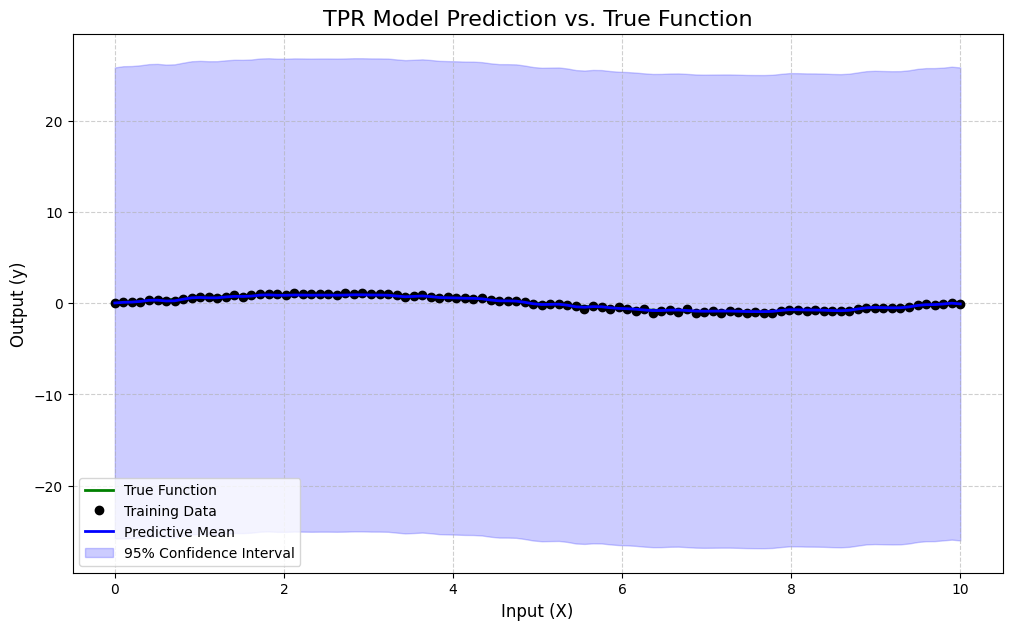

Plot window opened. Close the plot window to exit the script.


In [2]:

import matplotlib.pyplot as plt

def visualize_predictions(X_train, y_train, X_test, y_test_true, predictions):
    """
    Generates and displays a plot of the model's predictions.

    Args:
        X_train (torch.Tensor): Training input data.
        y_train (torch.Tensor): Training target data.
        X_test (torch.Tensor): Test input data.
        y_test_true (torch.Tensor): True values for the test data.
        predictions (dict): The output from the model's predict() method.
    """
    # Move tensors to CPU and convert to NumPy for plotting
    X_train_np = X_train.cpu().numpy()
    y_train_np = y_train.cpu().numpy()
    X_test_np = X_test.cpu().numpy()
    y_test_true_np = y_test_true.cpu().numpy()
    
    pred_mean = predictions['loc'].cpu().numpy()
    pred_scale_sq = predictions['scale_sq'].cpu().numpy()
    pred_std = np.sqrt(pred_scale_sq)
    
    # Calculate the 95% confidence interval
    lower_bound = pred_mean - 1.96 * pred_std
    upper_bound = pred_mean + 1.96 * pred_std
    
    # Create the plot
    plt.figure(figsize=(12, 7))
    
    # Plot the true function
    plt.plot(X_test_np, y_test_true_np, 'g-', label='True Function', linewidth=2)
    
    # Plot the training data points
    plt.plot(X_train_np, y_train_np, 'ko', label='Training Data', markersize=6)
    
    # Plot the model's predictive mean
    plt.plot(X_test_np, pred_mean, 'b-', label='Predictive Mean', linewidth=2)
    
    # Shade the confidence interval
    plt.fill_between(
        X_test_np.squeeze(), 
        lower_bound, 
        upper_bound, 
        color='blue', 
        alpha=0.2, 
        label='95% Confidence Interval'
    )
    
    # Add titles and labels for clarity
    plt.title('TPR Model Prediction vs. True Function', fontsize=16)
    plt.xlabel('Input (X)', fontsize=12)
    plt.ylabel('Output (y)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
# --- Configure logging to see model output ---
logging.basicConfig(level=logging.INFO, format='%(message)s')

# --- Generate Synthetic Data ---
torch.manual_seed(42)
N_train = 100
N_test = 100

# Training data
X_train = torch.linspace(0, 10, N_train).unsqueeze(-1)
y_train_true = torch.sin(X_train * (2 * np.pi / 10)) + torch.randn(X_train.shape) * 0.1
y_train = y_train_true.squeeze()

# Test data
X_test = torch.linspace(0, 10, N_test).unsqueeze(-1)
y_test = torch.sin(X_test * (2 * np.pi / 10)).squeeze()

# --- Initialize the Model ---
# You can customize initial hyperparameters and their optimization mode here
hyper_settings = {
    'lengthscale': {'optim': 'MLE'},
    'outputscale': {'optim': 'FIX', 'init': 1.0},
    'noisescale':  {'optim': 'MLE'},
    'dof_func':    {'optim': 'MLE'}, # Fix the functional DoF
    'dof_lik':     {'optim': 'MLE'},  # Learn the likelihood DoF
}

# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}\n")

# The TPR class is now available to be instantiated
model = TPR(X_train, y_train, hyper_settings=hyper_settings, device=device)

# --- Train the Model ---
# The fit method will run the optimization loop and print progress
training_history = model.fit(epochs=1000, hyper_lr=0.01, X_test=X_test, y_test=y_test, eval_interval=20)

# --- Make Predictions ---
print("\n--- Making Predictions ---")
predictions = model.predict(X_test)

pred_mean = predictions['loc']
pred_scale_sq = predictions['scale_sq']
pred_dof = predictions['dof']

# Calculate 95% confidence interval (approximate) from scale
pred_std = torch.sqrt(pred_scale_sq)
lower_bound = pred_mean - 1.96 * pred_std
upper_bound = pred_mean + 1.96 * pred_std

# --- Print Results ---
print(f"\nPredicted Mean (first 5 values): {pred_mean.cpu().numpy()[:5]}")
print(f"Predicted Scale^2 (first 5 values): {pred_scale_sq.cpu().numpy()[:5]}")
print(f"Predicted Degrees of Freedom: {pred_dof.item()}")

final_rmse = np.sqrt(mean_squared_error(y_test.cpu().numpy(), pred_mean.cpu().numpy()))
print(f"\nFinal Test RMSE: {final_rmse:.4f}")

# --- Visualize the Results ---
print("\n--- Visualizing Results ---")
# Note: Using `y_train_true` for a cleaner plot of noisy training data
visualize_predictions(X_train, y_train_true, X_test, y_test, predictions)
print("Plot window opened. Close the plot window to exit the script.")


Sampled initial lengthscale (Optim mode: MAP): [0.56026463]
Using provided initial outputscale (Optim mode: FIX): 1.0
Sampled initial dof_func (Optim mode: MAP): 2.1928902979671316
Sampled initial dof_lik (Optim mode: MAP): 2.0
Sampled initial noisescale (Optim mode: MAP): 0.009754817183031183
Starting SVI optimization for 100000 epochs...
Epoch   20/100000 | Fit Time: 0.007s | ELBO: -13337106.92 | l: [0.462] | var: 1.000 | noise_var: 0.012 | dof_f: 1.81 | dof_l: 2.41
Epoch   20/100000 | Test RMSE: 0.6798


Using device: cuda



Epoch   40/100000 | Fit Time: 0.007s | ELBO: -4849420.87 | l: [0.398] | var: 1.000 | noise_var: 0.013 | dof_f: 1.54 | dof_l: 2.45
Epoch   40/100000 | Test RMSE: 0.6722
Epoch   60/100000 | Fit Time: 0.007s | ELBO: -1774555.08 | l: [0.356] | var: 1.000 | noise_var: 0.014 | dof_f: 1.38 | dof_l: 2.10
Epoch   60/100000 | Test RMSE: 0.6651
Epoch   80/100000 | Fit Time: 0.007s | ELBO: -757057.40 | l: [0.326] | var: 1.000 | noise_var: 0.015 | dof_f: 1.29 | dof_l: 1.85
Epoch   80/100000 | Test RMSE: 0.6585
Epoch  100/100000 | Fit Time: 0.007s | ELBO: -387266.85 | l: [0.306] | var: 1.000 | noise_var: 0.015 | dof_f: 1.24 | dof_l: 1.68
Epoch  100/100000 | Test RMSE: 0.6524
Epoch  120/100000 | Fit Time: 0.009s | ELBO: -228663.62 | l: [0.292] | var: 1.000 | noise_var: 0.016 | dof_f: 1.20 | dof_l: 1.53
Epoch  120/100000 | Test RMSE: 0.6469
Epoch  140/100000 | Fit Time: 0.007s | ELBO: -149251.65 | l: [0.282] | var: 1.000 | noise_var: 0.017 | dof_f: 1.17 | dof_l: 1.41
Epoch  140/100000 | Test RMSE: 0.6


--- Making Predictions ---

Predicted Mean (first 5 values): [0.02774262 0.09619062 0.1384489  0.17702463 0.32343877]
Predicted Scale^2 (first 5 values): [0.01138457 0.01053516 0.0101193  0.01003718 0.01003206]
Predicted Degrees of Freedom: 153.21604687698084

Final Test RMSE: 0.0768

--- Visualizing Results ---


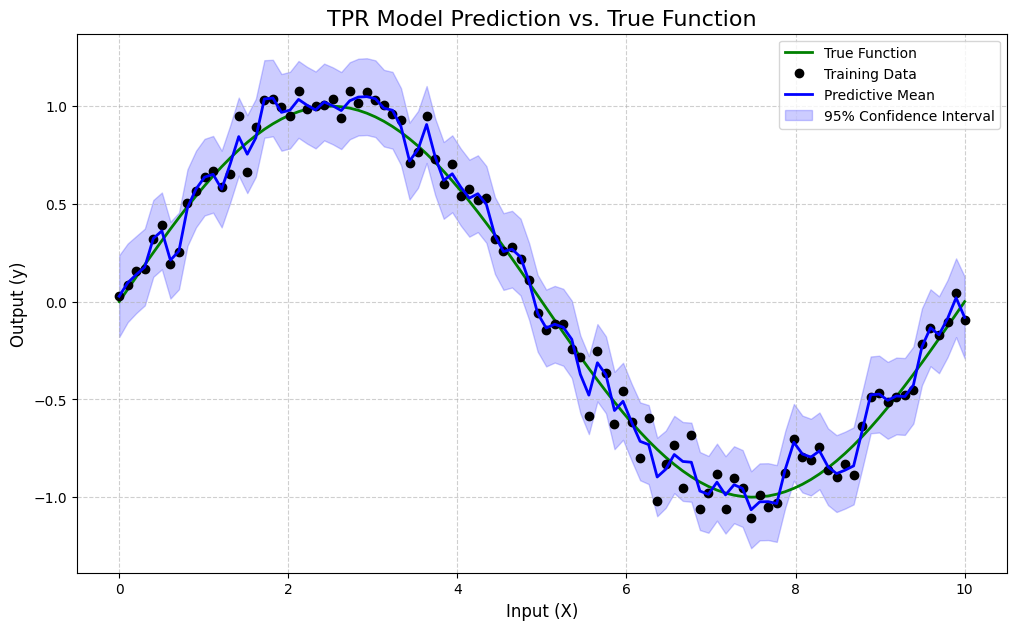

Plot window opened. Close the plot window to exit the script.


In [8]:

import matplotlib.pyplot as plt

def visualize_predictions(X_train, y_train, X_test, y_test_true, predictions):
    """
    Generates and displays a plot of the model's predictions.

    Args:
        X_train (torch.Tensor): Training input data.
        y_train (torch.Tensor): Training target data.
        X_test (torch.Tensor): Test input data.
        y_test_true (torch.Tensor): True values for the test data.
        predictions (dict): The output from the model's predict() method.
    """
    # Move tensors to CPU and convert to NumPy for plotting
    X_train_np = X_train.cpu().numpy()
    y_train_np = y_train.cpu().numpy()
    X_test_np = X_test.cpu().numpy()
    y_test_true_np = y_test_true.cpu().numpy()
    
    pred_mean = predictions['loc'].cpu().numpy()
    pred_scale_sq = predictions['scale_sq'].cpu().numpy()
    pred_std = np.sqrt(pred_scale_sq)
    
    # Calculate the 95% confidence interval
    lower_bound = pred_mean - 1.96 * pred_std
    upper_bound = pred_mean + 1.96 * pred_std
    
    # Create the plot
    plt.figure(figsize=(12, 7))
    
    # Plot the true function
    plt.plot(X_test_np, y_test_true_np, 'g-', label='True Function', linewidth=2)
    
    # Plot the training data points
    plt.plot(X_train_np, y_train_np, 'ko', label='Training Data', markersize=6)
    
    # Plot the model's predictive mean
    plt.plot(X_test_np, pred_mean, 'b-', label='Predictive Mean', linewidth=2)
    
    # Shade the confidence interval
    plt.fill_between(
        X_test_np.squeeze(), 
        lower_bound, 
        upper_bound, 
        color='blue', 
        alpha=0.2, 
        label='95% Confidence Interval'
    )
    
    # Add titles and labels for clarity
    plt.title('TPR Model Prediction vs. True Function', fontsize=16)
    plt.xlabel('Input (X)', fontsize=12)
    plt.ylabel('Output (y)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
# --- Configure logging to see model output ---
logging.basicConfig(level=logging.INFO, format='%(message)s')

# --- Generate Synthetic Data ---
torch.manual_seed(42)
N_train = 100
N_test = 100

# Training data
X_train = torch.linspace(0, 10, N_train).unsqueeze(-1)
y_train_true = torch.sin(X_train * (2 * np.pi / 10)) + torch.randn(X_train.shape) * 0.1
y_train = y_train_true.squeeze()

# Test data
X_test = torch.linspace(0, 10, N_test).unsqueeze(-1)
y_test = torch.sin(X_test * (2 * np.pi / 10)).squeeze()

# --- Initialize the Model ---
# You can customize initial hyperparameters and their optimization mode here
hyper_settings = {
    'lengthscale': {'optim': 'MAP'},
    'outputscale': {'optim': 'FIX', 'init': 1.0},
    'noisescale':  {'optim': 'MAP'},
    'dof_func':    {'optim': 'MAP'}, # Fix the functional DoF
    'dof_lik':     {'optim': 'MAP'},  # Learn the likelihood DoF
}

# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}\n")

# The TPR class is now available to be instantiated
model = TPR(X_train, y_train, hyper_settings=hyper_settings, device=device)

# --- Train the Model ---
# The fit method will run the optimization loop and print progress
training_history = model.fit(epochs=100000, hyper_lr=0.01, X_test=X_test, y_test=y_test, eval_interval=20)

# --- Make Predictions ---
print("\n--- Making Predictions ---")
predictions = model.predict(X_test)

pred_mean = predictions['loc']
pred_scale_sq = predictions['scale_sq']
pred_dof = predictions['dof']

# Calculate 95% confidence interval (approximate) from scale
pred_std = torch.sqrt(pred_scale_sq)
lower_bound = pred_mean - 1.96 * pred_std
upper_bound = pred_mean + 1.96 * pred_std

# --- Print Results ---
print(f"\nPredicted Mean (first 5 values): {pred_mean.cpu().numpy()[:5]}")
print(f"Predicted Scale^2 (first 5 values): {pred_scale_sq.cpu().numpy()[:5]}")
print(f"Predicted Degrees of Freedom: {pred_dof.item()}")

final_rmse = np.sqrt(mean_squared_error(y_test.cpu().numpy(), pred_mean.cpu().numpy()))
print(f"\nFinal Test RMSE: {final_rmse:.4f}")

# --- Visualize the Results ---
print("\n--- Visualizing Results ---")
# Note: Using `y_train_true` for a cleaner plot of noisy training data
visualize_predictions(X_train, y_train_true, X_test, y_test, predictions)
print("Plot window opened. Close the plot window to exit the script.")